
**Libraries**

In [34]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from IPython.display import display


**Uploading** **data &Cleaning**

In [35]:
train_df = pd.read_csv('aug_train.csv')

#Shows information first 5 rows in data
print(train_df.head())

print("##################################################")



#Shows information last 5 rows in data
print(train_df.tail())

print("##################################################")

#shows how many rows and columns in data
print(train_df.shape)

print("##################################################")

#Tells you about dataset
print(train_df.info())

print("##################################################")

#shows datatypes
print(train_df.dtypes)

print("##################################################")

#shows fast conclusion
print(train_df.describe())

print("##################################################")

#shows null values
print(train_df.isnull().sum())

print("##################################################")


   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   
3        33241  city_115                   0.789    NaN   
4          666  city_162                   0.767   Male   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enrollment        Graduate   
1   No relevent experience       no_enrollment        Graduate   
2   No relevent experience    Full time course        Graduate   
3   No relevent experience                 NaN        Graduate   
4  Has relevent experience       no_enrollment         Masters   

  major_discipline experience company_size    company_type last_new_job  \
0             STEM        >20          NaN             NaN            1   
1             STEM         15        50-99         Pvt Ltd           >4   
2             STEM     

**Cleaning Date**

In [36]:
for col in train_df.columns:
    if train_df[col].dtype == 'object':
        train_df[col].fillna(train_df[col].mode()[0], inplace=True)
    else:
        train_df[col].fillna(train_df[col].median(), inplace=True)

**Encoding**

In [37]:
label_encoders = {}
for col in train_df.select_dtypes(include=['object']).columns:
    if col != 'enrollee_id':
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col])
        label_encoders[col] = le

**Splitting data**

In [38]:
x = train_df.drop(['enrollee_id', 'target'], axis=1)
y = train_df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


**Scalling**

In [39]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Logistic Regression**

In [40]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(x_train_scaled, y_train)
lr_pred = lr_model.predict(x_test_scaled)

**Random Forest**

In [27]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

**Model evaluation**

In [29]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"{model_name}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("-" * 35)

evaluate_model(y_test, lr_pred, "Logistic Regression")
evaluate_model(y_test, rf_pred, "Random Forest")


Logistic Regression
Accuracy:  0.7633
Precision: 0.5510
Recall:    0.2553
F1 Score:  0.3489
Confusion Matrix:
[[2682  198]
 [ 709  243]]
-----------------------------------
Random Forest
Accuracy:  0.7659
Precision: 0.5382
Recall:    0.4065
F1 Score:  0.4632
Confusion Matrix:
[[2548  332]
 [ 565  387]]
-----------------------------------


**Visualizations**

/tmp/ipykernel_920/2941513405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=train_df, palette='Set2')


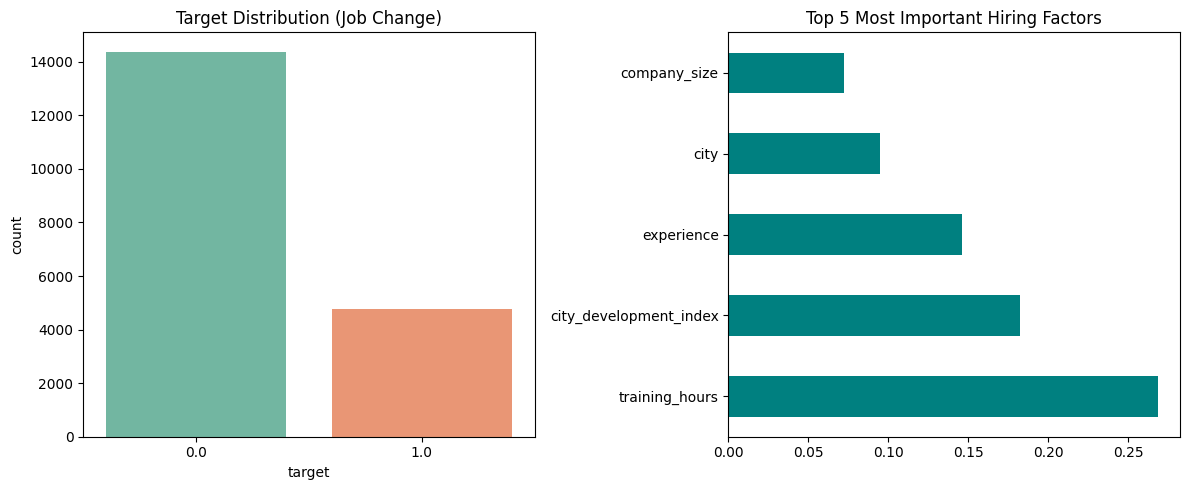

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='target', data=train_df, palette='Set2')
plt.title('Target Distribution (Job Change)')

plt.subplot(1, 2, 2)
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(5).plot(kind='barh', color='teal')
plt.title('Top 5 Most Important Hiring Factors')

plt.tight_layout()
plt.show()